In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter
from nltk import ngrams
import re
import tqdm
from collections import defaultdict

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

VALIDATION_PATH = "../../data/processed/validation_bio.csv"
SUBMISSION_PATH = "../../data/raw/submission.csv"
TRAIN_BIO_PATH = "../../data/processed/train_bio.csv"

In [2]:
df_val = pd.read_csv(VALIDATION_PATH, sep=";")
df_sub = pd.read_csv(SUBMISSION_PATH, sep=";")

df_val['tokens'] = df_val['tokens'].apply(ast.literal_eval)
df_sub['tokens'] = df_sub['sample'].str.split()

Сравнение длин запросов

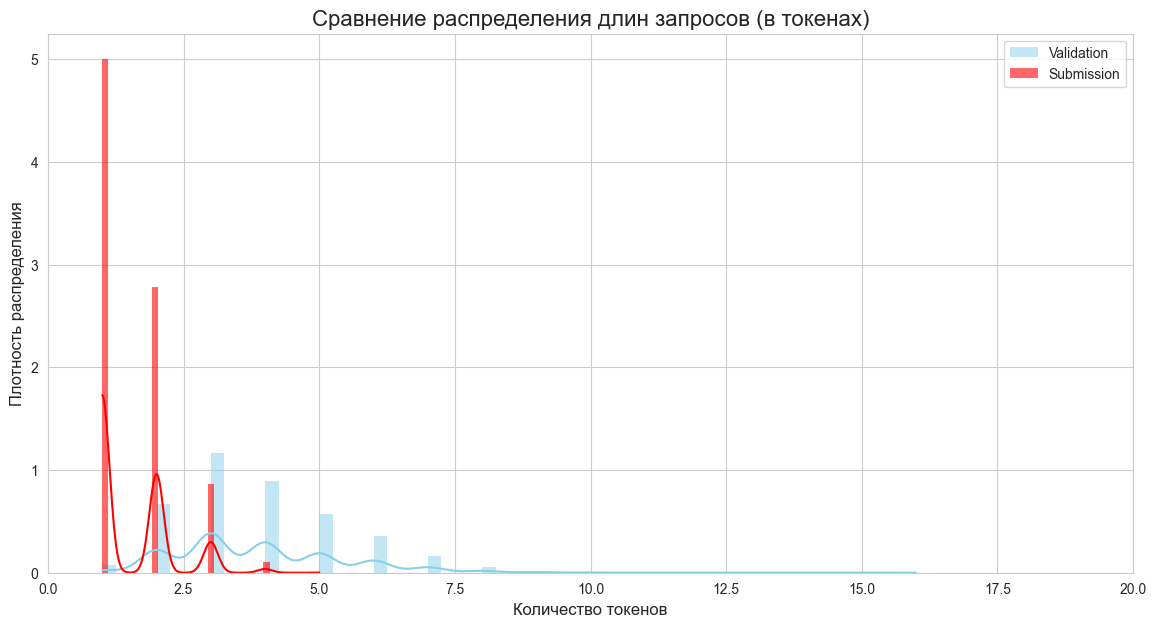

In [3]:
df_val['token_count'] = df_val['tokens'].apply(len)
df_sub['token_count'] = df_sub['tokens'].apply(len)

plt.figure(figsize=(14, 7))
sns.histplot(df_val['token_count'], color="skyblue", label='Validation', kde=True, stat="density", linewidth=0)
sns.histplot(df_sub['token_count'], color="red", label='Submission', kde=True, stat="density", linewidth=0, alpha=0.6)
plt.title('Сравнение распределения длин запросов (в токенах)', fontsize=16)
plt.xlabel('Количество токенов', fontsize=12)
plt.ylabel('Плотность распределения', fontsize=12)
plt.legend()
plt.xlim(0, 20)
# TODO plt.savefig("../../notebooks/iteration-1/charts/len_distribution_comparison.png")
plt.show()

Сравнение мультиязычности запросов

In [4]:
def contains_latin(text):
    return bool(re.search('[a-zA-Z]', text))

df_val['has_latin'] = df_val['sample'].apply(contains_latin)
df_sub['has_latin'] = df_sub['sample'].apply(contains_latin)

val_latin_ratio = df_val['has_latin'].mean() * 100
sub_latin_ratio = df_sub['has_latin'].mean() * 100

print(f"\nАнализ мультиязычности:")
print(f"  - Доля запросов с латиницей в Validation: {val_latin_ratio:.2f}%")
print(f"  - Доля запросов с латиницей в Submission: {sub_latin_ratio:.2f}%")


Анализ мультиязычности:
  - Доля запросов с латиницей в Validation: 13.45%
  - Доля запросов с латиницей в Submission: 14.52%


Коэффициент Жаккара (доля словарного пересечения)

In [5]:
vocab_val = set(token.lower() for tokens_list in df_val['tokens'] for token in tokens_list)
vocab_sub = set(token.lower() for tokens_list in df_sub['tokens'] for token in tokens_list)

intersection_size = len(vocab_val.intersection(vocab_sub))
union_size = len(vocab_val.union(vocab_sub))
jaccard_coefficient = intersection_size / union_size if union_size > 0 else 0

print(f"\nАнализ словарного пересечения:")
print(f"  - Размер словаря Validation: {len(vocab_val)}")
print(f"  - Размер словаря Submission: {len(vocab_sub)}")
print(f"  - Количество общих слов: {intersection_size}")
print(f"  - Коэффициент Жаккара: {jaccard_coefficient:.4f}")


Анализ словарного пересечения:
  - Размер словаря Validation: 3165
  - Размер словаря Submission: 5405
  - Количество общих слов: 183
  - Коэффициент Жаккара: 0.0218


Сравнение топ-20 одиночных токенов

In [6]:
counter_val_unigrams = Counter(token.lower() for tokens_list in df_val['tokens'] for token in tokens_list)
counter_sub_unigrams = Counter(token.lower() for tokens_list in df_sub['tokens'] for token in tokens_list)

top_20_val = counter_val_unigrams.most_common(20)
top_20_sub = counter_sub_unigrams.most_common(20)

df_top_unigrams = pd.DataFrame({
    'Validation Top 20': [f"'{word}' ({count})" for word, count in top_20_val],
    'Submission Top 20': [f"'{word}' ({count})" for word, count in top_20_sub]
})
print("\nСравнение 20 самых частотных токенов:")
print(df_top_unigrams.to_string())
df_top_unigrams.to_csv("../../data/processed/top_unigrams_comparison.csv", sep=";", index=False)


Сравнение 20 самых частотных токенов:
   Validation Top 20 Submission Top 20
0          '▁' (571)       'для' (153)
1          'е' (155)          'с' (93)
2          'о' (152)       'хлеб' (39)
3         '▁с' (149)          'в' (39)
4          'а' (140)        'сыр' (35)
5          'и' (136)        'чай' (31)
6          'н' (130)        'сок' (27)
7         'ки' (129)        'без' (25)
8          'к' (124)       'вода' (24)
9       '▁для' (123)         'из' (21)
10        'ка' (118)   'приправа' (20)
11         'ы' (107)       'соус' (16)
12       '▁сыр' (95)    'печенье' (16)
13        'ная' (93)    'красная' (16)
14          'й' (88)       'корм' (16)
15        '▁со' (81)      'масло' (15)
16        'ный' (78)       'пюре' (15)
17          'я' (72)     'творог' (15)
18        'ные' (70)     'прочие' (14)
19         '▁в' (64)       'гель' (14)


Сравнение топ-20 биграмм

In [7]:
def get_bigrams(tokens_series):
    bigrams = []
    for tokens_list in tokens_series:
        bigrams.extend(ngrams([token.lower() for token in tokens_list], 2))
    return bigrams

counter_val_bigrams = Counter(get_bigrams(df_val['tokens']))
counter_sub_bigrams = Counter(get_bigrams(df_sub['tokens']))

top_20_val_bi = counter_val_bigrams.most_common(20)
top_20_sub_bi = counter_sub_bigrams.most_common(20)

df_top_bigrams = pd.DataFrame({
    'Validation Top 20': [f"'{' '.join(bigram)}' ({count})" for bigram, count in top_20_val_bi],
    'Submission Top 20': [f"'{' '.join(bigram)}' ({count})" for bigram, count in top_20_sub_bi]
})
print("\nСравнение 20 самых частотных биграмм:")
print(df_top_bigrams.to_string())
df_top_bigrams.to_csv("../../data/processed/top_bigrams_comparison.csv", sep=";", index=False)


Сравнение 20 самых частотных биграмм:
    Validation Top 20    Submission Top 20
0   '▁при права' (23)  'красная цена' (10)
1       '▁кур и' (22)   'приправа для' (8)
2         '▁ яй' (21)   'средство для' (7)
3         '▁й о' (19)        'с сыром' (7)
4       'о гурт' (18)      'для мытья' (6)
5    '▁кол баса' (18)       'соус для' (6)
6       '▁ пель' (17)     'корм сухой' (6)
7    '▁мор ожен' (16)      'булочка с' (5)
8     '▁твор ож' (16)       'с вишней' (5)
9     '▁пече нь' (14)     'без сахара' (4)
10      '▁ гель' (14)     'для посуды' (4)
11      '▁со си' (14)     'в томатном' (4)
12        'е ты' (14)        'с солью' (4)
13        'нь е' (13)        '2 литра' (4)
14       'о нез' (13)      'сухой для' (4)
15      'коп че' (13)     'специи для' (4)
16     '▁ох лаж' (13)      'тесто для' (4)
17    '▁art fru' (13)    'для выпечки' (3)
18     '▁конф е' (13)     'доя посуды' (3)
19      '▁о вся' (13)       'сок сады' (3)


Создание карты токен-множество

In [8]:
df_train = pd.read_csv(TRAIN_BIO_PATH, sep=";")
df_train['tokens'] = df_train['tokens'].apply(ast.literal_eval)
df_train['tags'] = df_train['tags'].apply(ast.literal_eval)
print(f"Загружен обучающий датасет размером {len(df_train)} записей.")

token_to_tags_map = defaultdict(set)

for index, row in tqdm.tqdm(df_train.iterrows(), total=len(df_train), desc="Построение карты токенов"):
    for token, tag in zip(row['tokens'], row['tags']):
        token_lower = token.lower()
        clean_tag = tag.split('-')[-1]
        token_to_tags_map[token_lower].add(clean_tag)

print(f"\nИнформация: Карта 'токен -> теги' успешно построена. Уникальных токенов: {len(token_to_tags_map)}")

Загружен обучающий датасет размером 23163 записей.


Построение карты токенов: 100%|██████████| 23163/23163 [00:01<00:00, 21753.38it/s]


Информация: Карта 'токен -> теги' успешно построена. Уникальных токенов: 6104


Топ-20 неоднозначных токенов

In [9]:
ambiguous_tokens = {}
for token, tags in token_to_tags_map.items():
    if len(tags) > 1:
        ambiguous_tokens[token] = sorted(list(tags))

print(f"Найдено {len(ambiguous_tokens)} неоднозначных токенов (могут иметь несколько разных тегов).")

token_counts = Counter(token.lower() for tokens_list in df_train['tokens'] for token in tokens_list)

ambiguous_report_data = []
for token, tags in ambiguous_tokens.items():
    ambiguous_report_data.append({
        "Токен": token,
        "Возможные теги": ", ".join(tags),
        "Частота в train": token_counts.get(token, 0)
    })

df_ambiguous_report = pd.DataFrame(ambiguous_report_data)
df_ambiguous_report = df_ambiguous_report.sort_values(by="Частота в train", ascending=False)

df_ambiguous_report.to_csv("../../data/processed/ambiguous_tokens_report.csv", sep=";", index=False)

print("\n--- Топ-20 самых частотных неоднозначных токенов ---")
print(df_ambiguous_report.head(20).to_string())

Найдено 2084 неоднозначных токенов (могут иметь несколько разных тегов).

--- Топ-20 самых частотных неоднозначных токенов ---
    Токен  Возможные теги  Частота в train
25      ▁  BRAND, O, TYPE             3071
159     е  BRAND, O, TYPE              993
41     ▁с  BRAND, O, TYPE              948
106    ки  BRAND, O, TYPE              769
114     к  BRAND, O, TYPE              750
76      о  BRAND, O, TYPE              748
66     ка  BRAND, O, TYPE              711
92      а  BRAND, O, TYPE              708
9    ▁для         O, TYPE              679
39      и  BRAND, O, TYPE              662
147     ы  BRAND, O, TYPE              654
30      н  BRAND, O, TYPE              574
122   ная  BRAND, O, TYPE              547
6    ▁сыр  BRAND, O, TYPE              497
33    ные  BRAND, O, TYPE              449
124     я  BRAND, O, TYPE              449
238     й  BRAND, O, TYPE              430
93      ь  BRAND, O, TYPE              418
8     ный  BRAND, O, TYPE              410
16    ▁со  BR

Топ-5 "хамелеонов"

In [10]:
def analyze_token_context(token_to_analyze, df):
    print(f"\n--- Анализ контекста для токена: '{token_to_analyze}' ---")
    
    found_contexts = []
    for index, row in df.iterrows():
        tokens = row['tokens']
        tags = row['tags']
        
        for i, token in enumerate(tokens):
            if token.lower() == token_to_analyze:
                context_str = []
                for j, t in enumerate(tokens):
                    if i == j:
                        context_str.append(f"▶{t}◀[{tags[j]}]")
                    else:
                        context_str.append(t)
                found_contexts.append(" ".join(context_str))
    
    if not found_contexts:
        print("Контексты не найдены.")
        return
        
    unique_contexts = sorted(list(set(found_contexts)))
    for context in unique_contexts[:15]:
        print(f"  - {context}")
    
    if len(unique_contexts) > 15:
        print(f"  - ... и еще {len(unique_contexts) - 15} контекстов.")

In [11]:
top_5_ambiguous = df_ambiguous_report.head(5)["Токен"].tolist()

for token in top_5_ambiguous:
    analyze_token_context(token, df_train)


--- Анализ контекста для токена: '▁' ---
  - ▁ atlan tic ▶▁◀[B-TYPE] тру
  - ▁ attache ▶▁◀[B-TYPE] каль кул ят
  - ▁ ари ант ▶▁◀[B-TYPE] сид
  - ▁ бад ьян ▶▁◀[B-BRAND] spice x pe
  - ▁ бли ны , ▶▁◀[B-TYPE] бл н чики
  - ▁ бли ны ▁с ▶▁◀[O] виш
  - ▁ бот инки ▶▁◀[B-BRAND] bris
  - ▁ бри тва ▶▁◀[B-BRAND] gil lette
  - ▁ вел ком ▶▁◀[B-TYPE] зе льц
  - ▁ вел ком ▶▁◀[B-TYPE] зе льцы
  - ▁ гель ▁для ▶▁◀[O] стри кт
  - ▁ гель ▁поро шок ▶▁◀[B-BRAND] ло ск
  - ▁ гель ▶▁◀[B-TYPE] ло ск
  - ▁ гель ▶▁◀[O] дл ▁бр ить я
  - ▁ гель ▶▁◀[O] лля ▁у мы вания
  - ... и еще 3056 контекстов.

--- Анализ контекста для токена: 'е' ---
  - ▁ аар о нное ▁из ▶е◀[O] ля
  - ▁ аци до ▶е◀[I-TYPE] фили н
  - ▁ бли ▶е◀[I-TYPE] ы
  - ▁ бру сни чно ▶е◀[I-TYPE]
  - ▁ вани лин ▁трап ▶е◀[I-BRAND]
  - ▁ вани лин ▁трап ▶е◀[I-BRAND] за
  - ▁ вао ень ▶е◀[I-TYPE]
  - ▁ ват ные ▁диск и ▁про ши ты ▶е◀[O] ▁без вор с овые
  - ▁ вине гр ▶е◀[I-TYPE]
  - ▁ инде йка ▁туш ▶е◀[I-TYPE] ная
  - ▁ инде йка ▁фил ▶е◀[I-TYPE]
  - ▁ инде йка ▁ф